# How indicators work

Mechanics of the indicator system in `mplchart.indicators` (pandas backend). For the polars backend, the same charts are driven by polars expressions instead — see the expressions notebook.

This page focuses on how indicators compose and plot; for a visual catalog of charts see the Gallery page.

In [1]:
from mplchart.chart import Chart
from mplchart.samples import sample_prices
from mplchart.primitives import Candlesticks, LinePlot, Stripes
from mplchart.indicators import SMA, EMA, ROC, RSI, MACD

prices = sample_prices()
prices.tail(3)

,open,high,low,close,volume
date,,,,,
2025-11-13,274.109985,276.700012,272.089996,272.950012,49602800
2025-11-14,271.049988,275.959991,269.600006,272.410004,47399300
2025-11-17,268.815002,270.489990,265.730011,267.459991,42862157


## Indicators are callables

An indicator is a small object holding its parameters. Applying it to a prices DataFrame — `SMA(20)(prices)` or equivalently `prices.pipe(SMA(20))` — returns a Series aligned to the prices index.

In [2]:
prices.pipe(SMA(20)).tail(3)

date
2025-11-13    267.093961
2025-11-14    268.112178
2025-11-17    268.385876
Name: close, dtype: float64

Some indicators produce multiple outputs and return a DataFrame instead, one column per output.

In [3]:
prices.pipe(MACD()).tail(3)

,macd,macdsignal,macdhist
date,,,
2025-11-13,5.443428,5.575386,-0.131958
2025-11-14,5.244467,5.509202,-0.264735
2025-11-17,4.633946,5.334151,-0.700204


## Plotting and panes

Pass indicators to `plot()` alongside primitives. Everything draws on the *current* pane — use `pane()` (or the `Pane` primitive) to switch panes; overlay indicators like `SMA` share the price scale, while oscillators like `RSI` typically get their own pane. Indicators label their legend entries automatically from their repr.

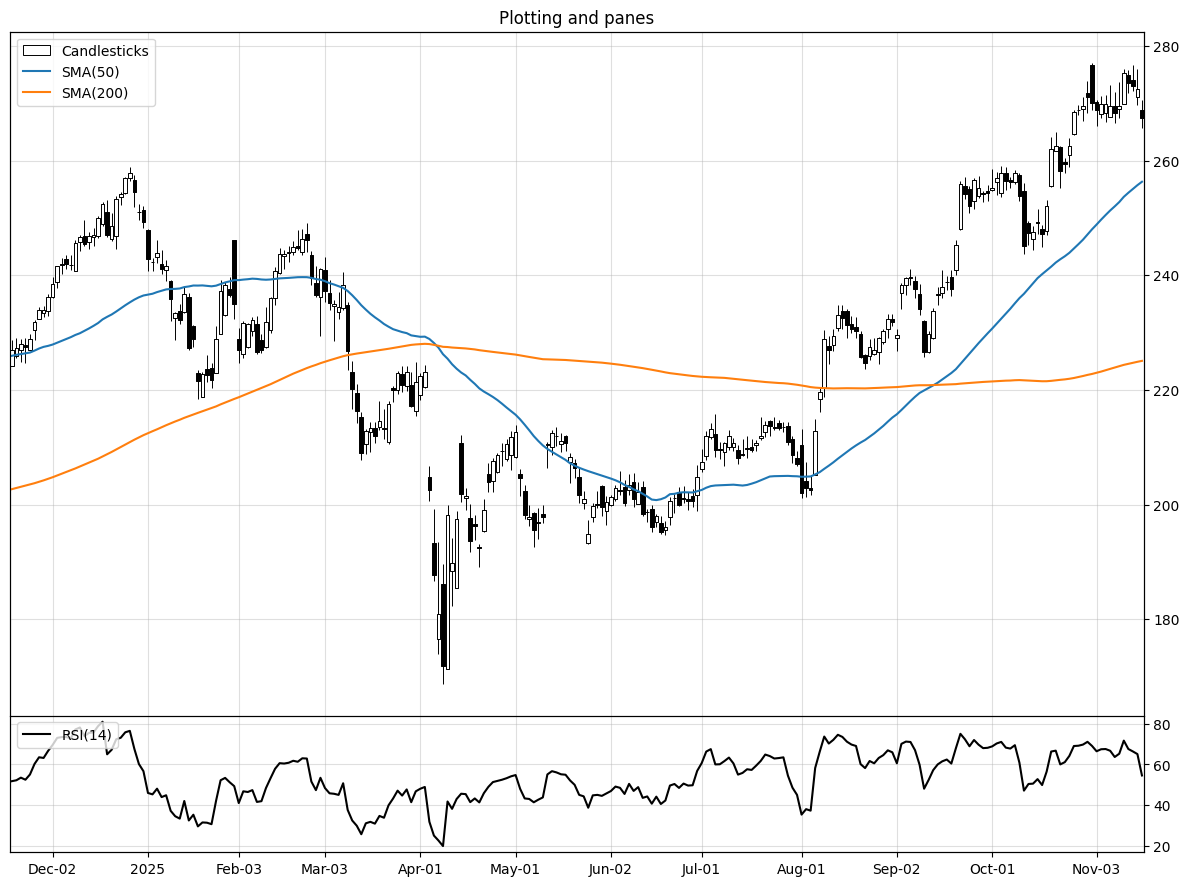

In [4]:
Chart(prices, title="Plotting and panes", max_bars=250).plot(
    Candlesticks(),
    SMA(50),
    SMA(200),
).pane("below").plot(
    RSI(14),
).show()

## Binding to primitives

By default indicators render with an automatic line plot. To control the rendering, pass the indicator to a primitive like `LinePlot` (or `AreaPlot`, `BarPlot`, `Stripes`, `Markers`). The operator form `RSI(14) @ LinePlot(...)` is an equivalent alternative to the constructor form.

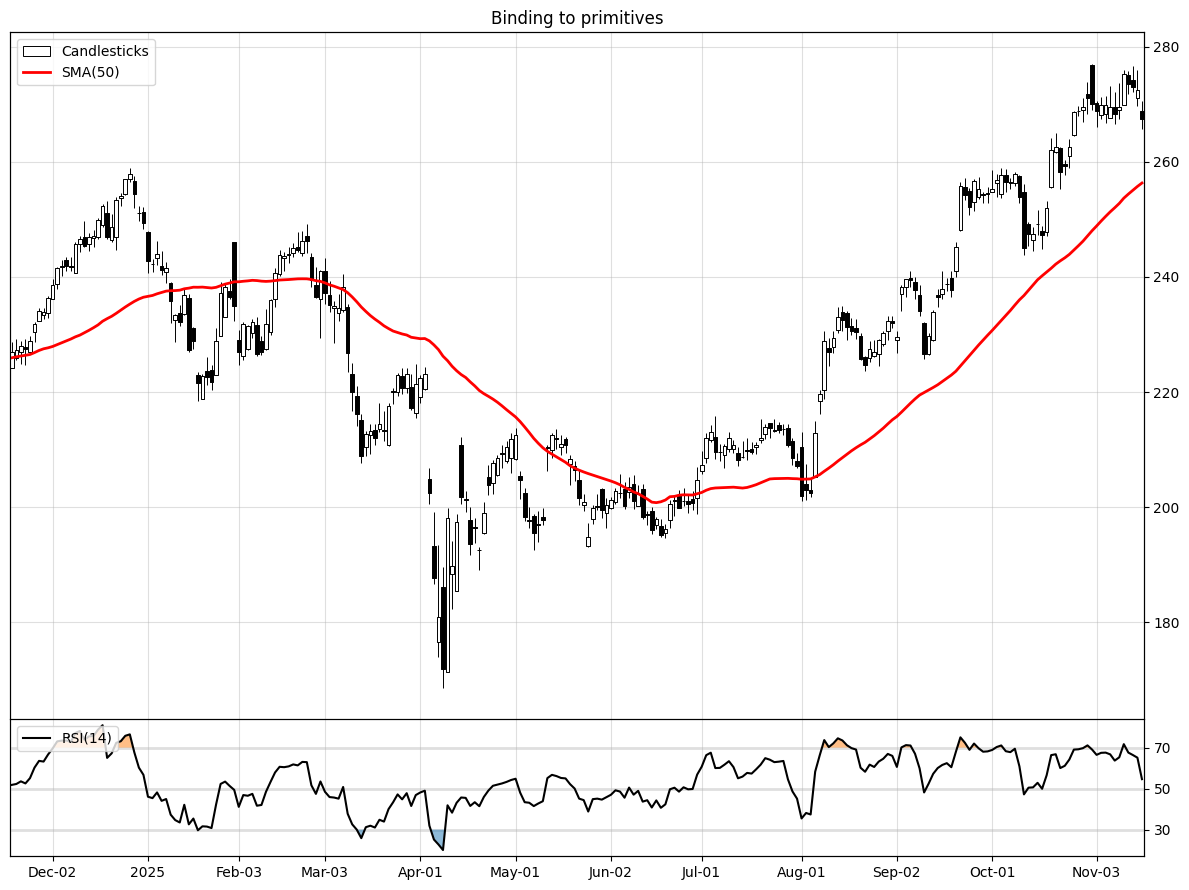

In [5]:
Chart(prices, title="Binding to primitives", max_bars=250).plot(
    Candlesticks(),
    LinePlot(SMA(50), color="red", width=2),
).pane("below", yticks=(30, 50, 70)).plot(
    LinePlot(RSI(14), overbought=70, oversold=30),
).show()

## Chaining indicators

The `|` operator chains indicators left-to-right: `EMA(20) | ROC(1)` computes `EMA(20)` from prices, then computes `ROC(1)` on that result. The chain is itself an indicator — callable, plottable, bindable.

In [6]:
smoothed_roc = EMA(20) | ROC(1)
smoothed_roc

EMA(20) | ROC(1)

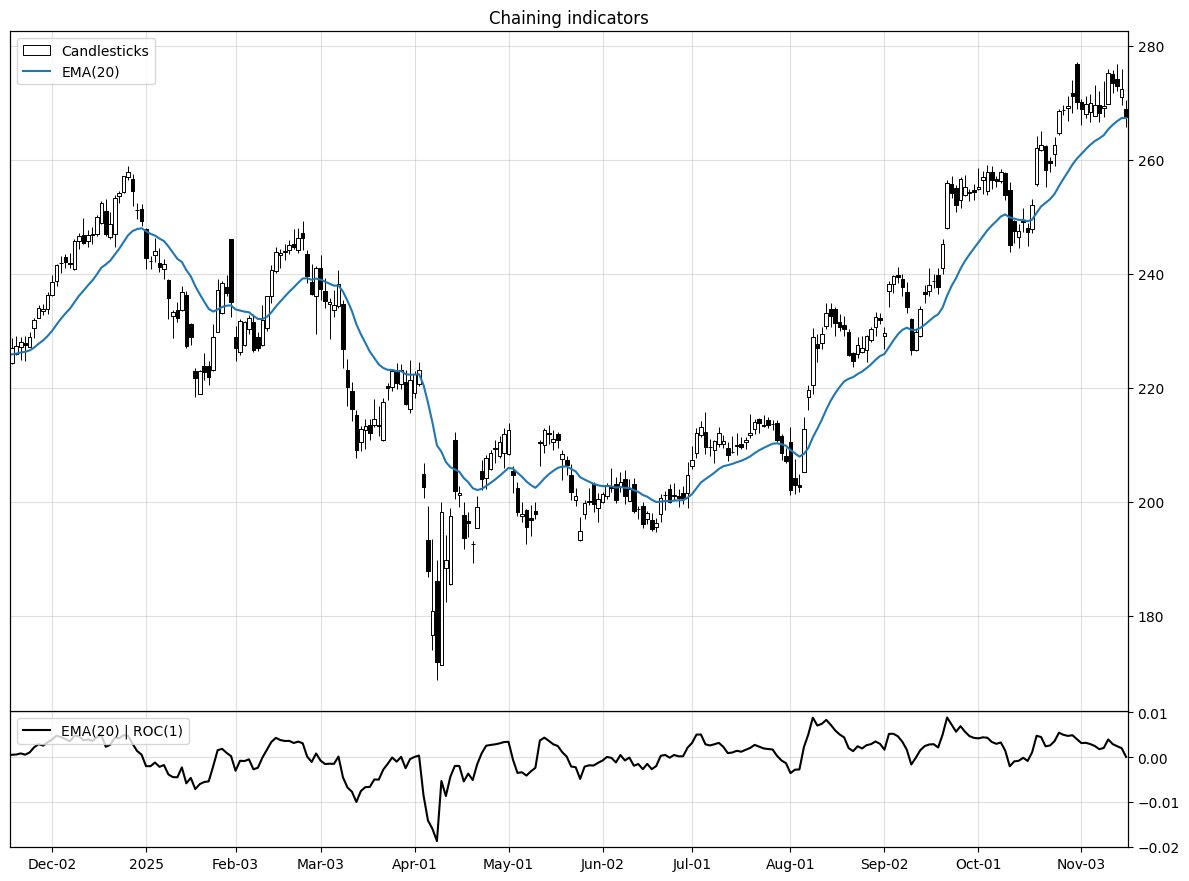

In [7]:
Chart(prices, title="Chaining indicators", max_bars=250).plot(
    Candlesticks(), EMA(20),
).pane("below").plot(
    smoothed_roc,
).show()

## Boolean composition

`as_expr()` wraps an indicator as a pandas expression (pandas ≥ 3.0), enabling boolean composition — useful with condition-driven primitives like `Stripes` or `Markers`. For multi-output indicators select a column first, e.g. `MACD().as_expr("macdhist") > 0`.

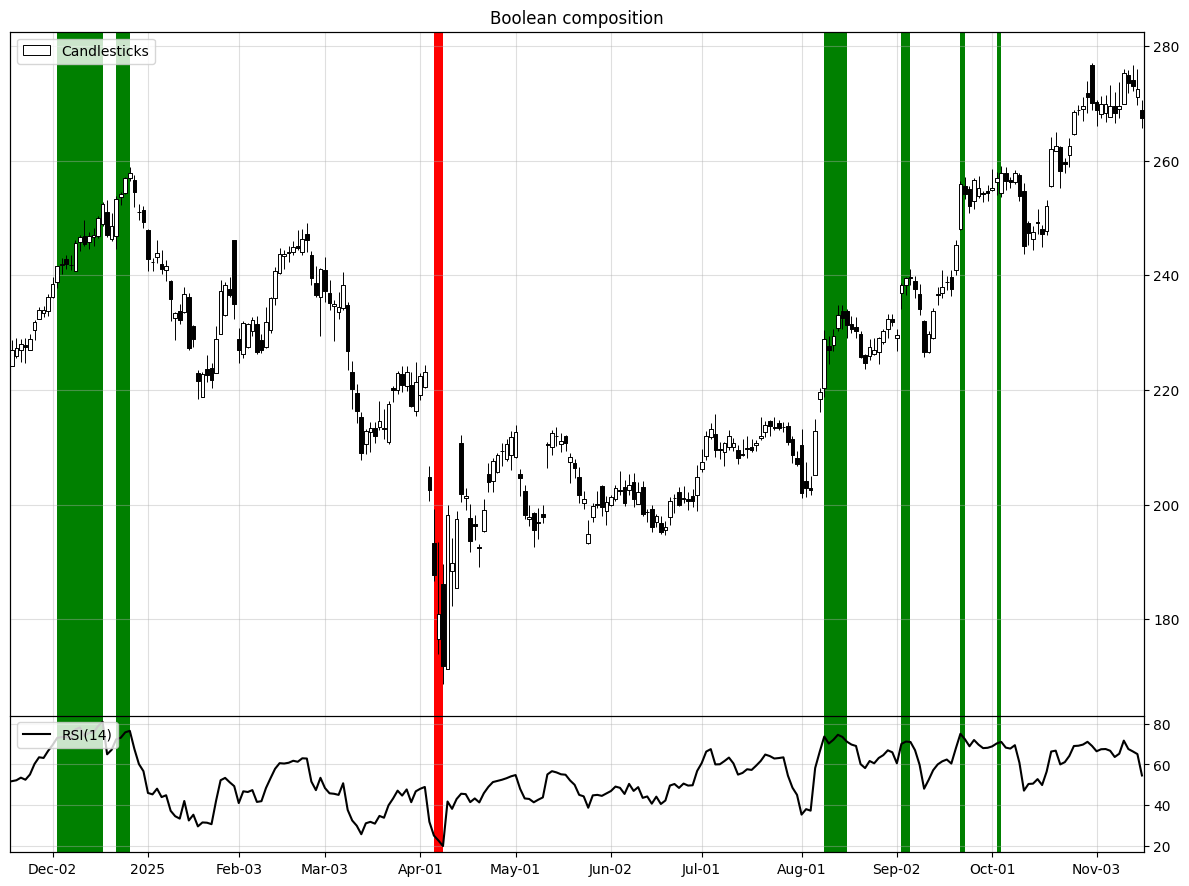

In [8]:
Chart(prices, title="Boolean composition", max_bars=250).plot(
    Candlesticks(),
    Stripes(RSI(14).as_expr() < 30, color="red"),
    Stripes(RSI(14).as_expr() > 70, color="green"),
).pane("below").plot(
    RSI(14),
).show()

## Custom indicators

Any callable taking a prices DataFrame and returning an aligned Series (or DataFrame) plots directly — a plain function is a valid indicator.

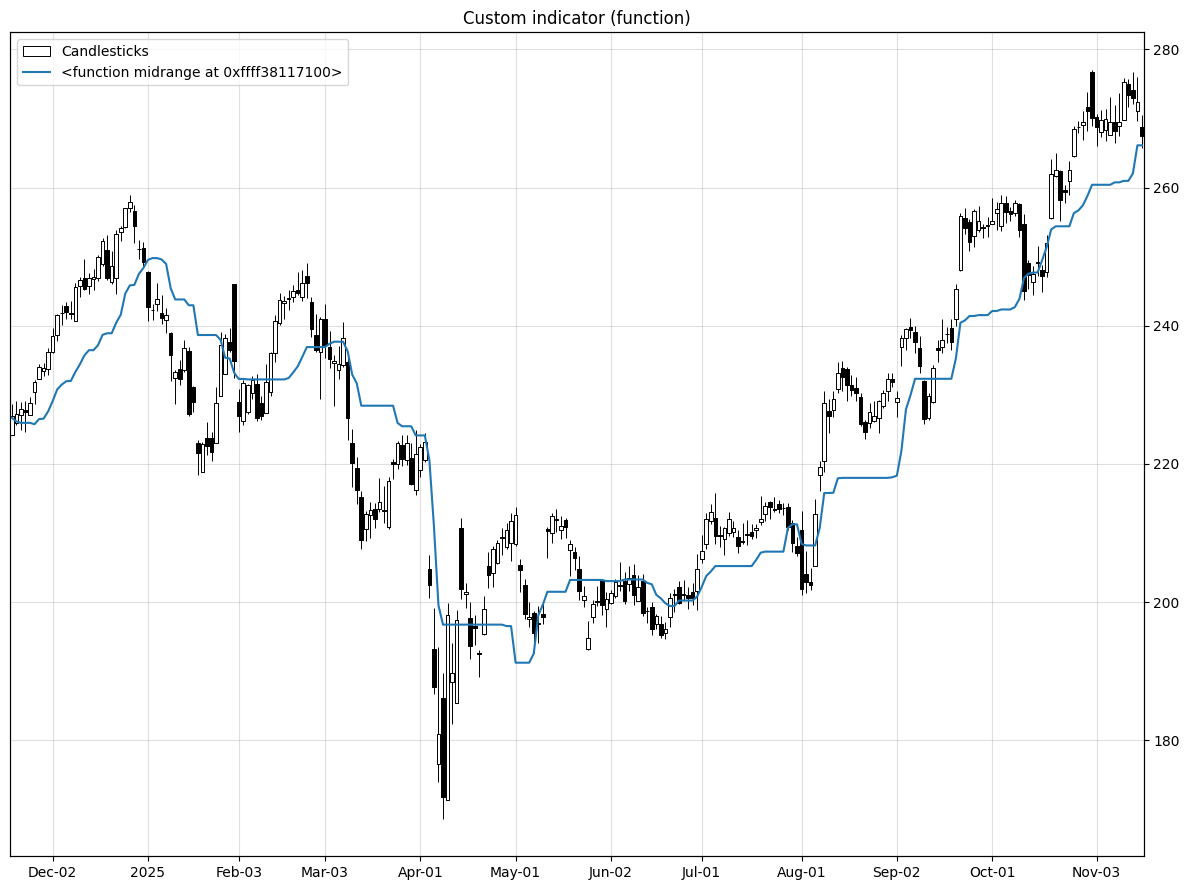

In [9]:
def midrange(prices, period=20):
    return (prices["high"].rolling(period).max() + prices["low"].rolling(period).min()) / 2


Chart(prices, title="Custom indicator (function)", max_bars=250).plot(
    Candlesticks(),
    midrange,
).show()

Subclassing `Indicator` adds the conveniences: parameters with a proper repr (used for the legend label), the `|` and `@` operators, and `get_series` for source-column handling. Implement `__init__` for parameters and `__call__` for the computation — the helpers in `mplchart.library` (`calc_sma`, `calc_ema`, ...) are available as building blocks.

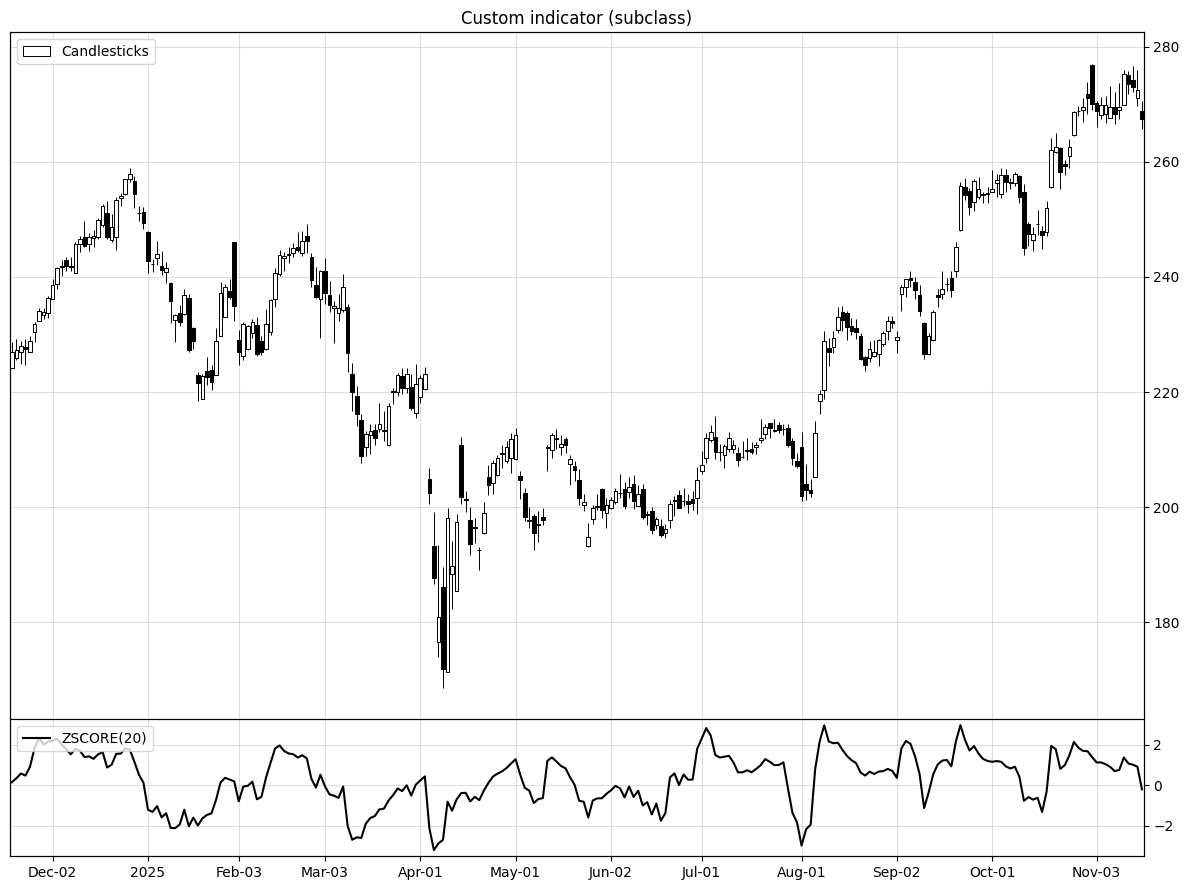

In [10]:
from mplchart.indicators import Indicator


class ZSCORE(Indicator):
    """Rolling z-score of the close price"""

    def __init__(self, period: int = 20):
        self.period = period

    def __call__(self, prices):
        series = self.get_series(prices)
        mean = series.rolling(self.period).mean()
        std = series.rolling(self.period).std()
        return (series - mean) / std


Chart(prices, title="Custom indicator (subclass)", max_bars=250).plot(
    Candlesticks(),
).pane("below").plot(
    ZSCORE(20),
).show()